In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

C:\Users\VAIBHAV\AppData\Local\Temp\ipykernel_7352\4108310712.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Libraries imported successfully


# Airbnb Hotel Booking Analysis

### Data Analytics Project

This project analyzes Airbnb listing data to identify patterns in pricing, room types, neighbourhoods, reviews, availability, host characteristics, and booking-related attributes.

In [2]:
file_path = "data/Airbnb_Hotel_Booking_Analysis_Cleaned.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,instant_bookable,...,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,No,...,2020.0,966.0,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,No,...,2007.0,142.0,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,Unknown,Elise,Manhattan,Harlem,40.80902,-73.94190,Yes,...,2005.0,620.0,124.0,3.0,0.0,NaT,NaN,5.0,1.0,352.0
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,Yes,...,2005.0,368.0,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,No,...,2009.0,204.0,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 102058
Number of columns: 22


In [5]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long',
       'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102058 entries, 0 to 102057
Data columns (total 22 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102058 non-null  int64         
 1   NAME                            101788 non-null  object        
 2   host id                         102058 non-null  int64         
 3   host_identity_verified          102058 non-null  object        
 4   host name                       101652 non-null  object        
 5   neighbourhood group             102058 non-null  object        
 6   neighbourhood                   102058 non-null  object        
 7   lat                             102050 non-null  float64       
 8   long                            102050 non-null  float64       
 9   instant_bookable                102058 non-null  object        
 10  cancellation_policy             102058 non-null  object 

In [7]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

last review                       15832
reviews per month                 15818
availability 365                    879
minimum nights                      448
host name                           406
review rate number                  319
calculated host listings count      319
service fee                         273
NAME                                270
price                               247
Construction year                   214
number of reviews                   183
lat                                   8
long                                  8
dtype: int64

In [8]:
print("Total duplicate rows:", df.duplicated().sum())
print("Duplicate listing IDs:", df["id"].duplicated().sum())

Total duplicate rows: 0
Duplicate listing IDs: 0


In [9]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
id,102058.0,29184376.600002,1001254.0,15092856.25,29184376.5,43275897.0,57367417.0,16271725.200849
host id,102058.0,49267380568.759804,123600518.0,24599236477.75,49128650907.5,74006192315.0,98763129024.0,28537415286.452332
lat,102050.0,40.728097,40.49979,40.68873,40.72229,40.76276,40.91697,0.055852
long,102050.0,-73.949652,-74.24984,-73.98258,-73.95444,-73.93235,-73.70522,0.049502
Construction year,101844.0,2012.48809,2003.0,2007.0,2012.0,2017.0,2022.0,5.765838
price,101811.0,625.35558,50.0,340.0,625.0,913.0,1200.0,331.672649
service fee,101785.0,125.039249,10.0,68.0,125.0,183.0,240.0,66.325905
minimum nights,101610.0,7.845842,1.0,2.0,3.0,5.0,365.0,17.065232
number of reviews,101875.0,27.517948,0.0,1.0,7.0,31.0,1024.0,49.571744
last review,86226,2019-06-11 02:12:22.996312064,2012-07-11 00:00:00,2018-10-27 00:00:00,2019-06-13 00:00:00,2019-07-05 00:00:00,2058-06-16 00:00:00,NaN


## 1. Data Wrangling

Data wrangling involves inspecting the dataset, identifying missing values and duplicate records, checking data types, and preparing the data for exploratory analysis.

## 2. Problem Statement

Airbnb generates a large amount of listing and booking-related data containing information about prices, room types, locations, reviews, availability, hosts and cancellation policies. However, raw data alone does not clearly reveal pricing patterns, location-based trends, listing characteristics and relationships between different variables.

The objective of this project is to analyze Airbnb listing data using Python-based data cleaning, exploratory data analysis and visualization techniques to identify meaningful patterns and insights.

## 3. Business Questions

The analysis aims to answer the following questions:

1. What are the different room/property types available in the dataset?
2. Which neighbourhood group has the highest number of listings?
3. What is the relationship between price and service fee?
4. How does host identity verification relate to review ratings?
5. Is there a relationship between calculated host listings count and availability?
6. How does average price vary across construction years?
7. How does average price vary across neighbourhood groups?
8. Which neighbourhoods have the highest average prices?
9. What is the distribution of cancellation policies?
10. What is the distribution of instant-bookable listings?

## 4. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to identify patterns, distributions and relationships between important Airbnb listing variables using statistical summaries and visualizations.

### Q1. What are the different room types available?

This analysis identifies the distribution of Airbnb listings across different room types.

In [10]:
room_counts = df["room type"].value_counts()

print(room_counts)

room type
Entire home/apt    53429
Private room       46306
Shared room         2208
Hotel room           115
Name: count, dtype: int64


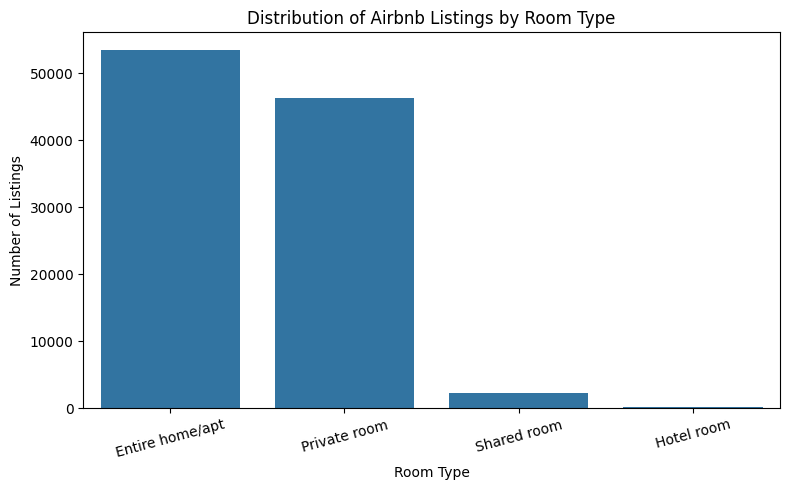

In [11]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="room type",
    order=df["room type"].value_counts().index
)

plt.title("Distribution of Airbnb Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig("outputs/charts/room_type_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

The analysis shows that Airbnb listings are distributed across multiple room types, with entire home/apartment and private room listings forming the major categories. Hotel rooms and shared rooms represent comparatively smaller portions of the dataset.

### Q2. Which neighbourhood group has the highest number of listings?

This analysis compares the number of Airbnb listings across different neighbourhood groups.

In [12]:
neighbourhood_counts = df["neighbourhood group"].value_counts()

print(neighbourhood_counts)

neighbourhood group
Manhattan        43558
Brooklyn         41631
Queens           13197
Bronx             2694
Staten Island      949
Unknown             29
Name: count, dtype: int64


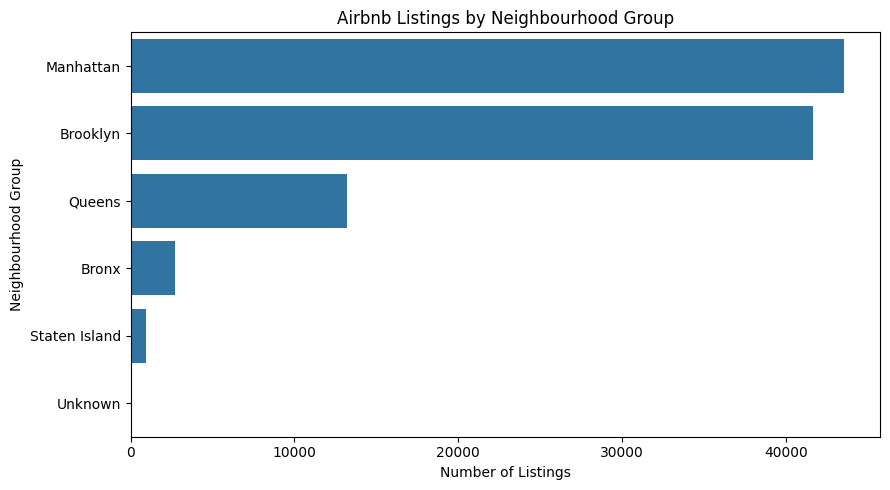

In [13]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    y="neighbourhood group",
    order=df["neighbourhood group"].value_counts().index
)

plt.title("Airbnb Listings by Neighbourhood Group")
plt.xlabel("Number of Listings")
plt.ylabel("Neighbourhood Group")
plt.tight_layout()

plt.savefig("outputs/charts/neighbourhood_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

Manhattan and Brooklyn account for the largest share of listings in the dataset, while Bronx and Staten Island contain substantially fewer listings.

### Q3. What is the relationship between price and service fee?

A scatter plot is used to examine whether Airbnb service fees tend to increase with listing price.

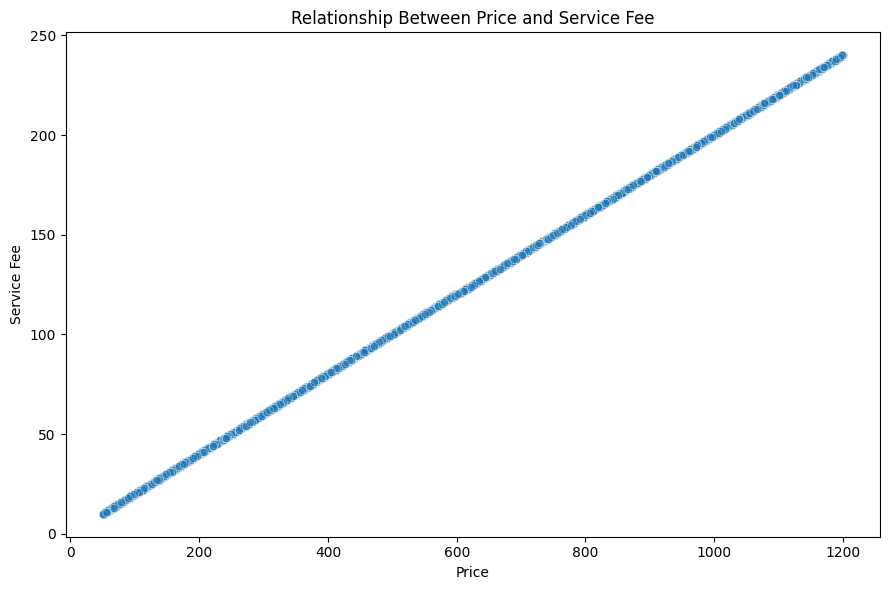

In [14]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df.sample(min(5000, len(df)), random_state=42),
    x="price",
    y="service fee",
    alpha=0.5
)

plt.title("Relationship Between Price and Service Fee")
plt.xlabel("Price")
plt.ylabel("Service Fee")
plt.tight_layout()

plt.savefig("outputs/charts/price_service_fee.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

The scatter plot helps identify the relationship between listing price and service fee. The points indicate that service fees generally vary with listing price, although substantial variation exists among individual listings.

### Q4. How does host identity verification relate to review ratings?

This analysis compares the average review rating between verified and unverified hosts.

In [15]:
verification_rating = (
    df.groupby("host_identity_verified")["review rate number"]
      .mean()
      .sort_values(ascending=False)
)

print(verification_rating)

host_identity_verified
verified       3.285675
unconfirmed    3.272033
Unknown        3.236364
Name: review rate number, dtype: float64


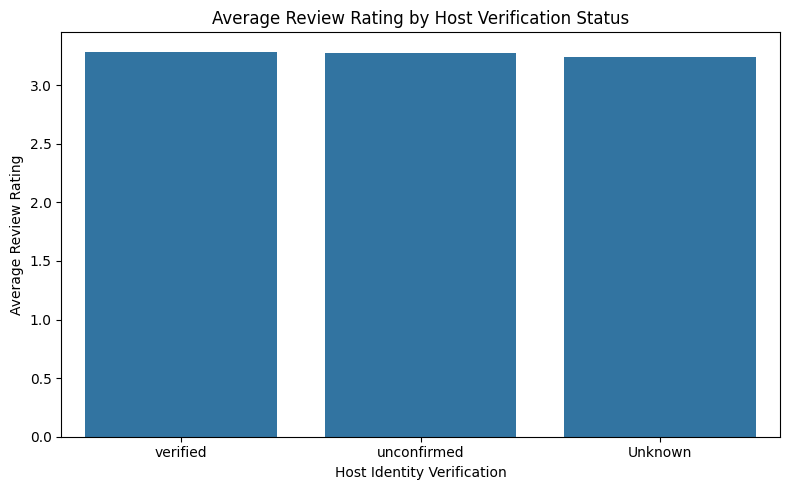

In [16]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=verification_rating.index,
    y=verification_rating.values
)

plt.title("Average Review Rating by Host Verification Status")
plt.xlabel("Host Identity Verification")
plt.ylabel("Average Review Rating")

plt.tight_layout()
plt.savefig("outputs/charts/verification_rating.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

The comparison shows how average review ratings differ between host verification groups. This provides an indication of whether verified host status is associated with differences in guest ratings.

### Q5. Is there a relationship between host listing count and availability?

This analysis examines whether hosts managing more listings show different availability patterns.

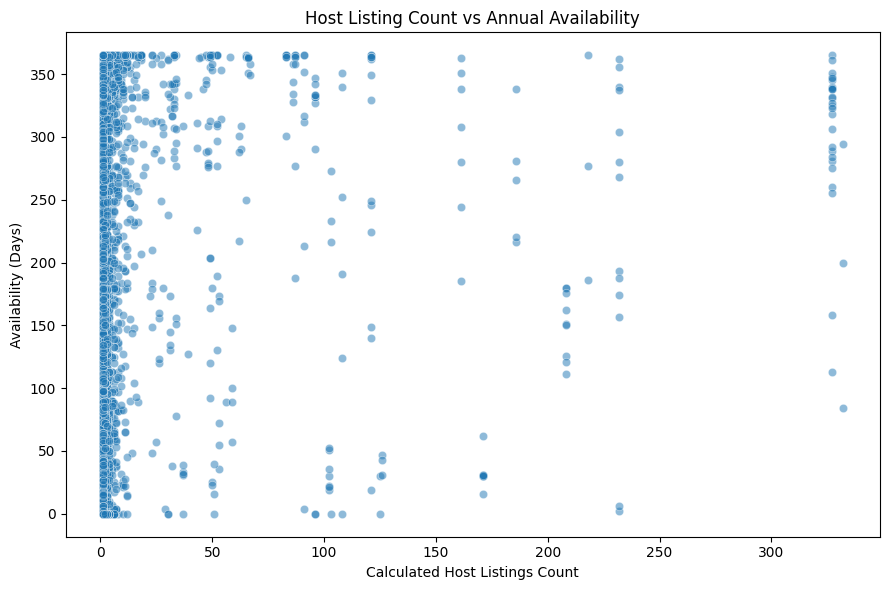

In [17]:
plt.figure(figsize=(9, 6))

sample_df = df.sample(min(5000, len(df)), random_state=42)

sns.scatterplot(
    data=sample_df,
    x="calculated host listings count",
    y="availability 365",
    alpha=0.5
)

plt.title("Host Listing Count vs Annual Availability")
plt.xlabel("Calculated Host Listings Count")
plt.ylabel("Availability (Days)")
plt.tight_layout()

plt.savefig("outputs/charts/host_availability.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

The scatter plot shows the relationship between the number of listings managed by a host and annual availability. The distribution can be used to identify whether hosts with larger portfolios have systematically different availability patterns.

### Q6. How does average price vary across construction years?

This analysis investigates whether property construction year is associated with differences in average listing price.

In [18]:
year_price = (
    df.groupby("Construction year")["price"]
      .mean()
      .sort_index()
)

print(year_price)

Construction year
2003.0    623.282681
2004.0    630.038639
2005.0    620.240079
2006.0    634.960773
2007.0    626.194444
2008.0    638.667374
2009.0    618.610483
2010.0    626.627271
2011.0    627.247708
2012.0    624.084103
2013.0    619.091365
2014.0    630.953524
2015.0    617.356663
2016.0    624.777599
2017.0    628.822956
2018.0    624.766500
2019.0    612.030039
2020.0    621.498438
2021.0    629.693816
2022.0    628.971361
Name: price, dtype: float64


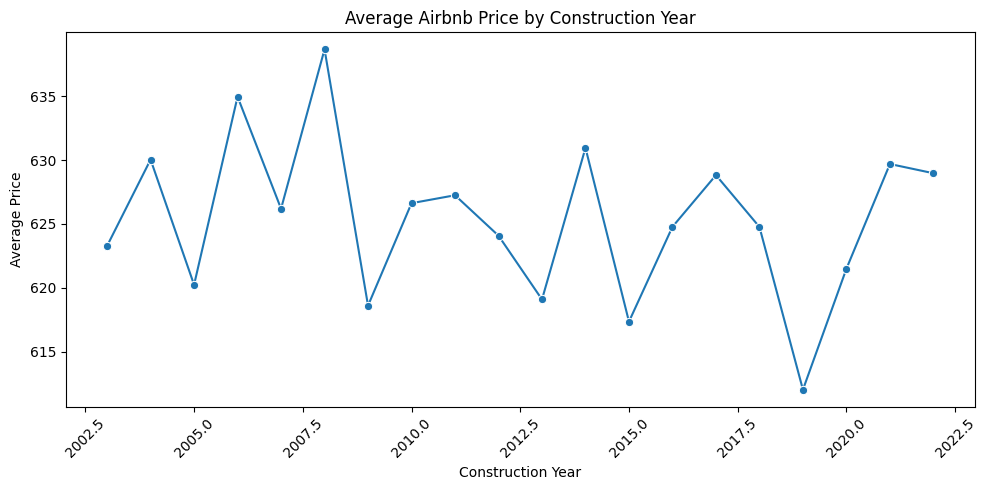

In [19]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=year_price.index,
    y=year_price.values,
    marker="o"
)

plt.title("Average Airbnb Price by Construction Year")
plt.xlabel("Construction Year")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("outputs/charts/construction_price.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

Average Airbnb prices vary across construction years. This analysis helps identify whether newer or older properties tend to have different average pricing levels.

### Q7. How does average price vary across neighbourhood groups?

This analysis compares average Airbnb prices across major neighbourhood groups.

In [20]:
avg_price_neighbourhood = (
    df.groupby("neighbourhood group")["price"]
      .mean()
      .sort_values(ascending=False)
)

print(avg_price_neighbourhood)

neighbourhood group
Unknown          658.357143
Queens           630.217031
Bronx            627.764793
Brooklyn         626.500843
Staten Island    623.990486
Manhattan        622.647187
Name: price, dtype: float64


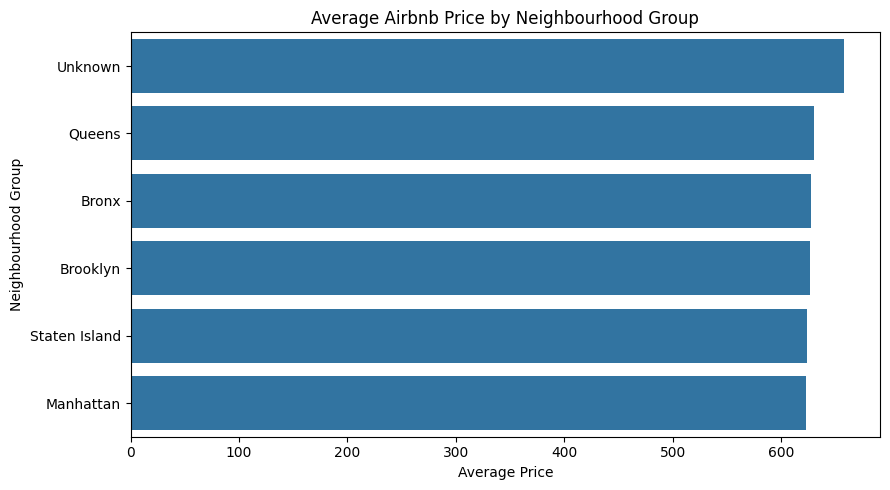

In [21]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=avg_price_neighbourhood.values,
    y=avg_price_neighbourhood.index
)

plt.title("Average Airbnb Price by Neighbourhood Group")
plt.xlabel("Average Price")
plt.ylabel("Neighbourhood Group")

plt.tight_layout()
plt.savefig("outputs/charts/neighbourhood_price.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

The average price comparison shows differences in pricing across neighbourhood groups. Location is therefore an important factor to consider when analyzing Airbnb listing prices.

# Q8. Top 10 Expensive Neighbourhoods

In [22]:
top_neighbourhoods = (
    df.groupby("neighbourhood")["price"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

print(top_neighbourhoods)

neighbourhood
New Dorp                  1045.000000
Chelsea, Staten Island    1042.000000
Fort Wadsworth            1024.000000
Little Neck                817.750000
Jamaica Hills              812.904762
Shore Acres                805.142857
Arden Heights              804.888889
Midland Beach              796.176471
Mill Basin                 775.142857
Riverdale                  768.736842
Name: price, dtype: float64


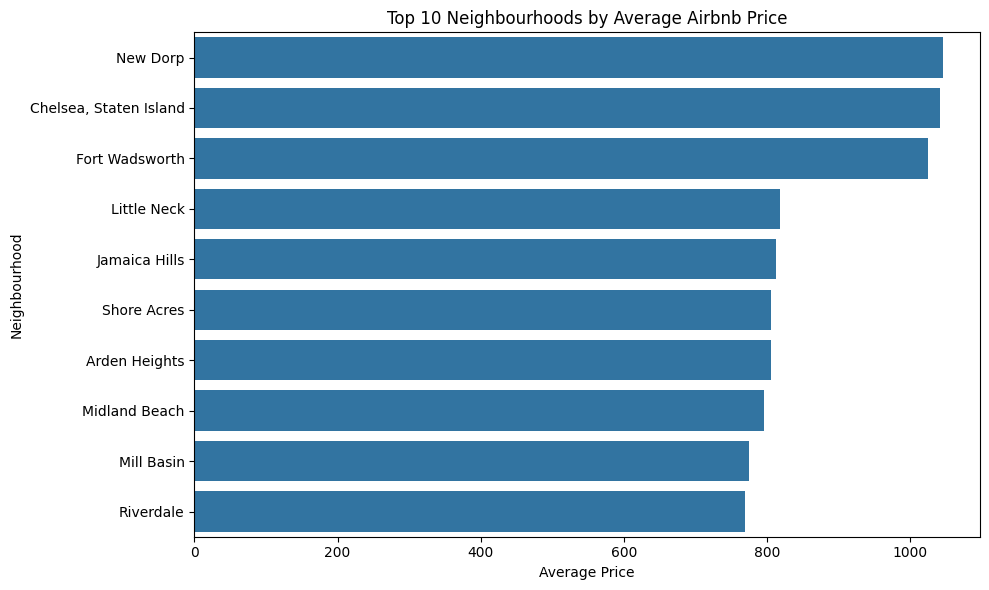

In [23]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_neighbourhoods.values,
    y=top_neighbourhoods.index
)

plt.title("Top 10 Neighbourhoods by Average Airbnb Price")
plt.xlabel("Average Price")
plt.ylabel("Neighbourhood")

plt.tight_layout()
plt.savefig("outputs/charts/top_10_neighbourhoods.png", dpi=300, bbox_inches="tight")
plt.show()

## Q9. Cancellation Policy

In [24]:
cancellation_counts = df["cancellation_policy"].value_counts()

print(cancellation_counts)

cancellation_policy
moderate    34162
strict      33929
flexible    33891
Unknown        76
Name: count, dtype: int64


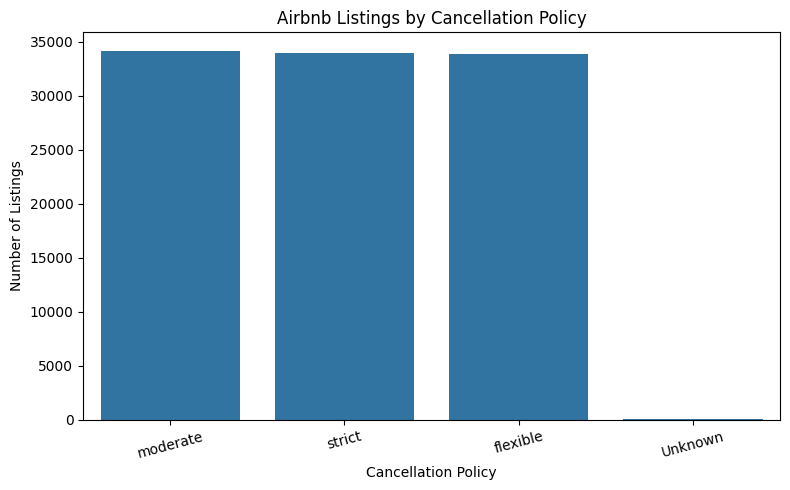

In [25]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="cancellation_policy",
    order=df["cancellation_policy"].value_counts().index
)

plt.title("Airbnb Listings by Cancellation Policy")
plt.xlabel("Cancellation Policy")
plt.ylabel("Number of Listings")
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig("outputs/charts/cancellation_policy.png", dpi=300, bbox_inches="tight")
plt.show()

Q10. Instant Booking

In [26]:
booking_counts = df["instant_bookable"].value_counts()

print(booking_counts)

instant_bookable
No         51186
Yes        50767
Unknown      105
Name: count, dtype: int64


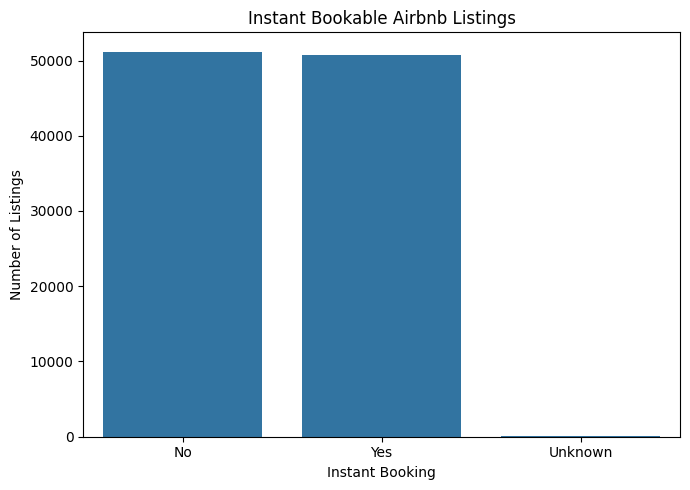

In [27]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="instant_bookable",
    order=df["instant_bookable"].value_counts().index
)

plt.title("Instant Bookable Airbnb Listings")
plt.xlabel("Instant Booking")
plt.ylabel("Number of Listings")

plt.tight_layout()
plt.savefig("outputs/charts/instant_booking.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Correlation Analysis

Correlation analysis is used to understand the strength and direction of relationships between important numerical variables.

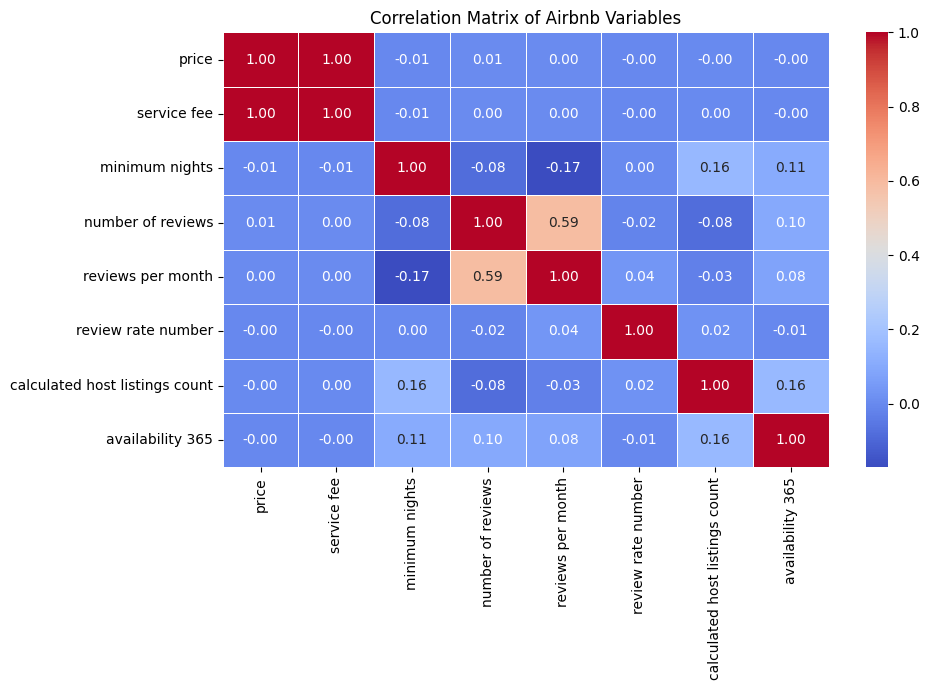

In [28]:
numeric_cols = [
    "price",
    "service fee",
    "minimum nights",
    "number of reviews",
    "reviews per month",
    "review rate number",
    "calculated host listings count",
    "availability 365"
]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Airbnb Variables")
plt.tight_layout()

plt.savefig("outputs/charts/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Key Insights

Based on the exploratory analysis, the following insights were identified:

1. Entire home/apartment and private room listings represent the majority of Airbnb inventory.

2. Manhattan and Brooklyn contain the highest concentration of listings among the neighbourhood groups.

3. Listing price and service fee show an observable relationship, although individual listings vary considerably.

4. Host identity verification can be compared with review ratings to identify differences between host categories.

5. Host portfolio size and annual availability show varying patterns across listings.

6. Average Airbnb prices differ across neighbourhood groups, demonstrating the importance of location in pricing.

7. Significant differences exist between neighbourhoods in terms of average listing price.

8. Cancellation policies and instant-booking options vary across Airbnb listings and provide additional insight into listing characteristics.

## 7. Conclusion

The Airbnb Hotel Booking Analysis project demonstrates how raw accommodation data can be transformed into meaningful business insights using Python, Pandas, Matplotlib and Seaborn.

The analysis examined room types, neighbourhood distribution, pricing, service fees, reviews, host characteristics, availability, cancellation policies and booking options.

The results show that location, room type and listing characteristics play important roles in Airbnb pricing and market distribution. The analysis can support hosts, property managers, customers and business analysts in understanding Airbnb market patterns and making data-driven decisions.